In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn

features = pd.read_csv('../data/feature_by_cluster.csv')
database = pd.read_csv('../data/nanopore_trace_database.csv')

# Visualization of Mean Current Distribution and other features to see what features can be used for classification(with 4 clusters)

#### Mean Current


for _, row in df_clusters.iterrows():
    aa = row['AA']
    cluster = row['cluster']
    if cluster == 1:
        CLUSTERS[aa] = '1, other'
    elif cluster == 2:
        CLUSTERS[aa] = '2, negative'
    elif cluster == 3:
        CLUSTERS[aa] = '3, large and hydrophobic'
    elif cluster == 4:
        CLUSTERS[aa] = '4, small'


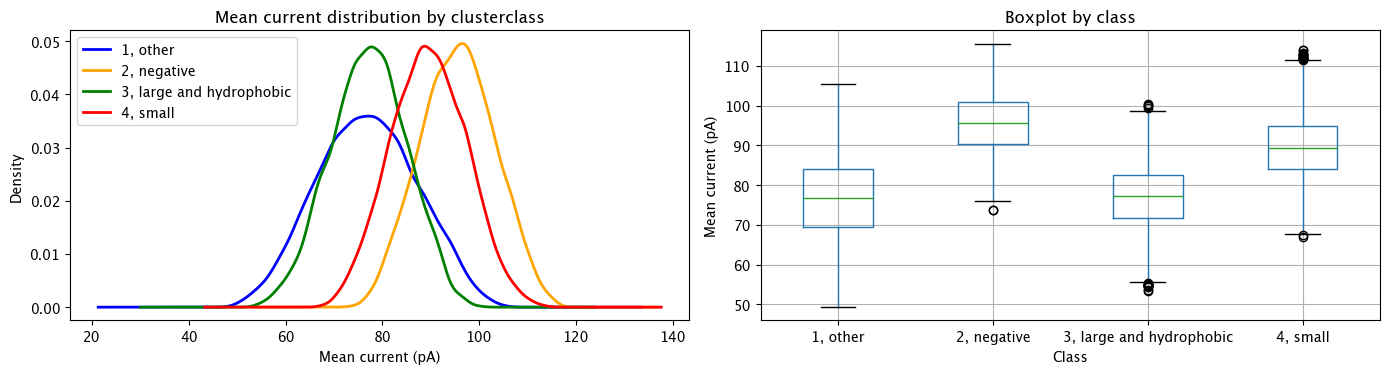

                            count   mean    std    min    25%    50%     75%  \
cluster_class                                                                  
1, other                  13983.0  76.87  10.23  49.33  69.54  76.80   84.10   
2, negative                4032.0  95.60   7.60  73.82  90.29  95.60  100.93   
3, large and hydrophobic   9993.0  77.14   7.82  53.46  71.75  77.27   82.58   
4, small                  11991.0  89.53   7.79  66.87  84.04  89.43   95.01   

                             max  
cluster_class                     
1, other                  105.43  
2, negative               115.63  
3, large and hydrophobic  100.35  
4, small                  114.02  


In [ ]:
CLUSTER_COLORS = {
    '1, other': 'blue',
    '2, negative': 'orange',
    '3, large and hydrophobic': 'green',
    '4, small': 'red'
}


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('cluster_class'):
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=CLUSTER_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Mean current distribution by clusterclass')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='mean_current', by='cluster_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('cluster_class')['mean_current'].describe().round(2))

#### Standard Deviation

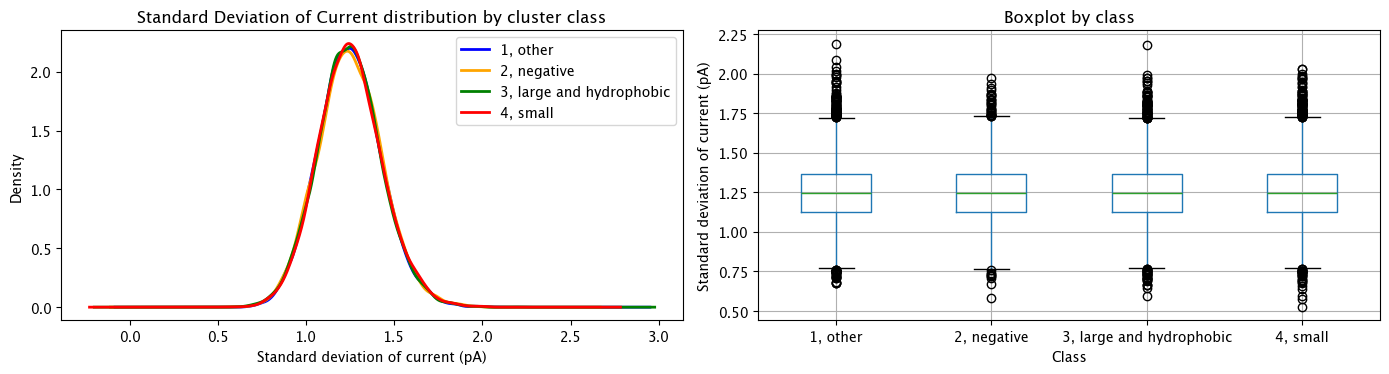

                            count  mean   std   min   25%   50%   75%   max
cluster_class                                                              
1, other                  13983.0  1.25  0.18  0.67  1.13  1.24  1.37  2.19
2, negative                4032.0  1.25  0.18  0.58  1.13  1.25  1.37  1.97
3, large and hydrophobic   9993.0  1.25  0.18  0.59  1.13  1.24  1.36  2.18
4, small                  11991.0  1.25  0.18  0.52  1.13  1.24  1.37  2.03


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('cluster_class'):
    grp['std_current'].plot.kde(ax=ax, label=cls, color=CLUSTER_COLORS[cls], linewidth=2)
ax.set_xlabel('Standard deviation of current (pA)')
ax.set_title('Standard Deviation of Current distribution by cluster class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='std_current', by='cluster_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Standard deviation of current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('cluster_class')['std_current'].describe().round(2))

#### Dwell Time

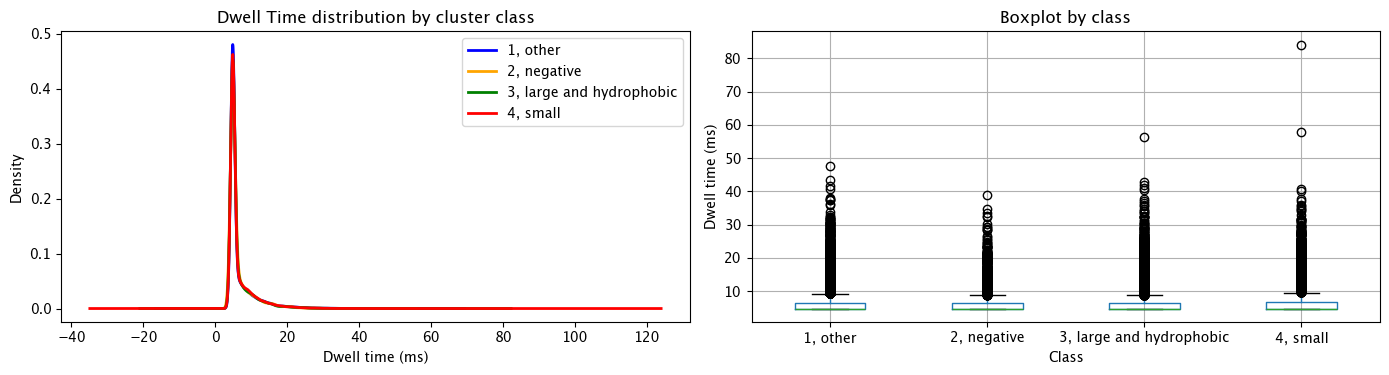

                            count  mean   std  min  25%  50%  75%   max
cluster_class                                                          
1, other                  13983.0  6.61  3.85  4.8  4.8  4.8  6.6  47.8
2, negative                4032.0  6.49  3.55  4.8  4.8  4.8  6.4  38.8
3, large and hydrophobic   9993.0  6.57  3.84  4.8  4.8  4.8  6.4  56.4
4, small                  11991.0  6.62  3.85  4.8  4.8  4.8  6.8  84.2


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in features.groupby('cluster_class'):
    grp['dwell_time'].plot.kde(ax=ax, label=cls, color=CLUSTER_COLORS[cls], linewidth=2)
ax.set_xlabel('Dwell time (ms)')
ax.set_title('Dwell Time distribution by cluster class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
features.boxplot(column='dwell_time', by='cluster_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Dwell time (ms)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(features.groupby('cluster_class')['dwell_time'].describe().round(2))

# Define order and mapping of classes and corresponding colors

In [12]:
CLUSTER_COLORS_4 = {
    '1, other': 'steelblue',
    '2, negative': 'orange',
    '3, large and hydrophobic': 'green',
    '4, small': 'red'
}

ORDER_4 = ['1, other', '2, negative', '3, large and hydrophobic', '4, small']   


#### Summary statistics per class

In [13]:
stats_table = features.groupby('cluster_class')['mean_current'].agg(
    n='count',
    mean='mean',
    std='std',
    p5=lambda x: x.quantile(0.05),
    p25=lambda x: x.quantile(0.25),
    median='median',
    p75=lambda x: x.quantile(0.75),
    p95=lambda x: x.quantile(0.95),
).round(2)

stats_table

,n,mean,std,p5,p25,median,p75,p95
cluster_class,,,,,,,,
"1, other",13983,76.87,10.23,60.12,69.54,76.80,84.10,93.98
"2, negative",4032,95.60,7.60,82.87,90.29,95.60,100.93,108.27
"3, large and hydrophobic",9993,77.14,7.82,64.19,71.75,77.27,82.58,90.06
"4, small",11991,89.53,7.79,76.64,84.04,89.43,95.01,102.34


# Classifiers

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# feature_cols = [
#     'mean_minus2', 'std_minus2', 'dwell_minus2',
#     'mean_minus1', 'std_minus1', 'dwell_minus1',
#     'mean_current', 'std_current', 'dwell_time',
#     'mean_plus1', 'std_plus1', 'dwell_plus1',
#     'mean_plus2', 'std_plus2', 'dwell_plus2',
# ]
feature_cols = [
    'mean_minus2', #'std_minus2', 'dwell_minus2',    
    'mean_minus1', #'std_minus1', 'dwell_minus1',
    'mean_current',# 'std_current', 'dwell_time',
    'mean_plus1', #'std_plus1', 'dwell_plus1',
    'mean_plus2',# 'std_plus2', 'dwell_plus2',
]


X = features[feature_cols].values
y = features['cluster_class'].values
mask = ~np.isnan(X).any(axis=1)
X, y = X[mask], y[mask]

models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced'))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

cv_results = {}
for name, model in models.items():
    result = cross_validate(model, X, y, cv=kf, scoring=scoring)
    cv_results[name] = {
        'macro F1':    (result['test_macro_f1'].mean(),    result['test_macro_f1'].std()),
        'weighted F1': (result['test_weighted_f1'].mean(), result['test_weighted_f1'].std()),
        'accuracy':    (result['test_accuracy'].mean(),    result['test_accuracy'].std()),
    }

# summary table: mean ± std across folds
rows = {}
for name, metrics in cv_results.items():
    rows[name] = {metric: f"{mean:.3f} ± {std:.3f}" for metric, (mean, std) in metrics.items()}

pd.DataFrame(rows).T

,macro F1,weighted F1,accuracy
GaussianNB,0.387 ± 0.006,0.412 ± 0.004,0.441 ± 0.002
LogisticRegression,0.573 ± 0.003,0.566 ± 0.004,0.569 ± 0.004
RandomForest,0.514 ± 0.009,0.540 ± 0.009,0.550 ± 0.008


In [21]:
from sklearn.model_selection import cross_val_predict

# get out-of-fold predictions for each model using the same CV split
# for name, model in models.items():
#     features[f'pred_{name}'] = cross_val_predict(model, X, y, cv=kf)
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=kf)
    features.loc[mask, f'pred_{name}'] = preds

# show one trace as an example
# trace = features[features['trace_id'] == 0].dropna(subset=[f'pred_{name}' for name in models]).sort_values('step_id')
# for name in models:
#     acc = (trace[f'pred_{name}'] == trace['phys_class']).mean()
#     print(f"{name:20s} (acc={acc:.2f}): {' - '.join(trace[f'pred_{name}'].tolist())}")
# print(f"{'actual':20s}         : {' - '.join(trace['phys_class'].tolist())}")
# print(f"{'amino acid':20s}         : {' - '.join(trace['amino_acid'].tolist())}")


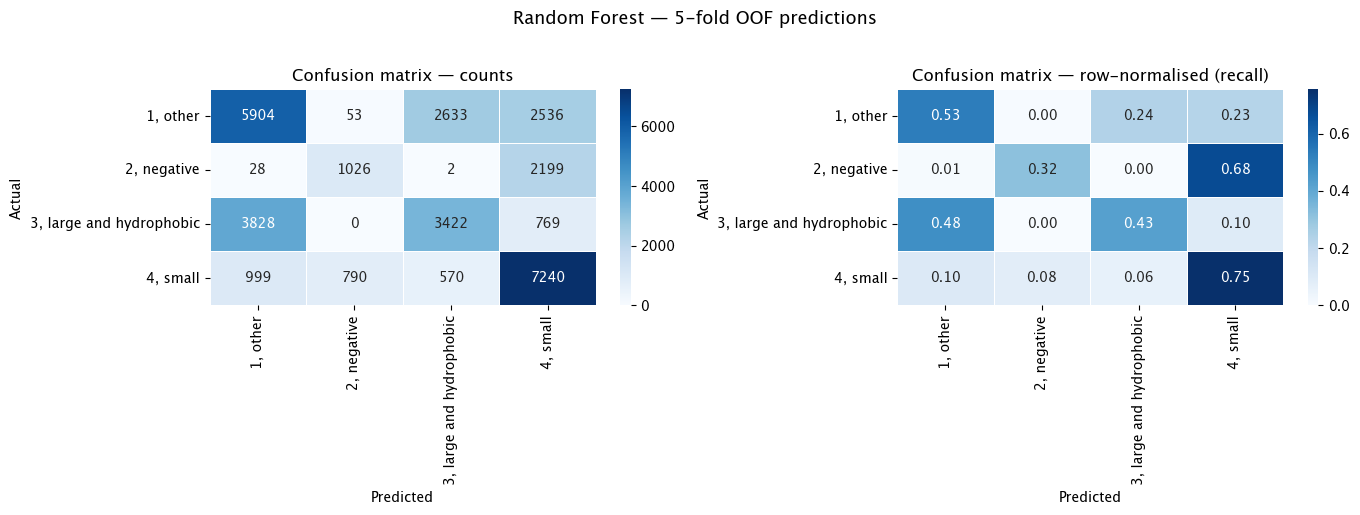

                          precision    recall  f1-score   support

                1, other       0.55      0.53      0.54     11126
             2, negative       0.55      0.32      0.40      3255
3, large and hydrophobic       0.52      0.43      0.47      8019
                4, small       0.57      0.75      0.65      9599

                accuracy                           0.55     31999
               macro avg       0.55      0.51      0.51     31999
            weighted avg       0.55      0.55      0.54     31999



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

valid = features.dropna(subset=['pred_RandomForest'])
y_true = valid['cluster_class']
y_pred = valid['pred_RandomForest']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_4)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)  # row-normalised (recall)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_4, yticklabels=ORDER_4,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Random Forest — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_4, target_names=ORDER_4))

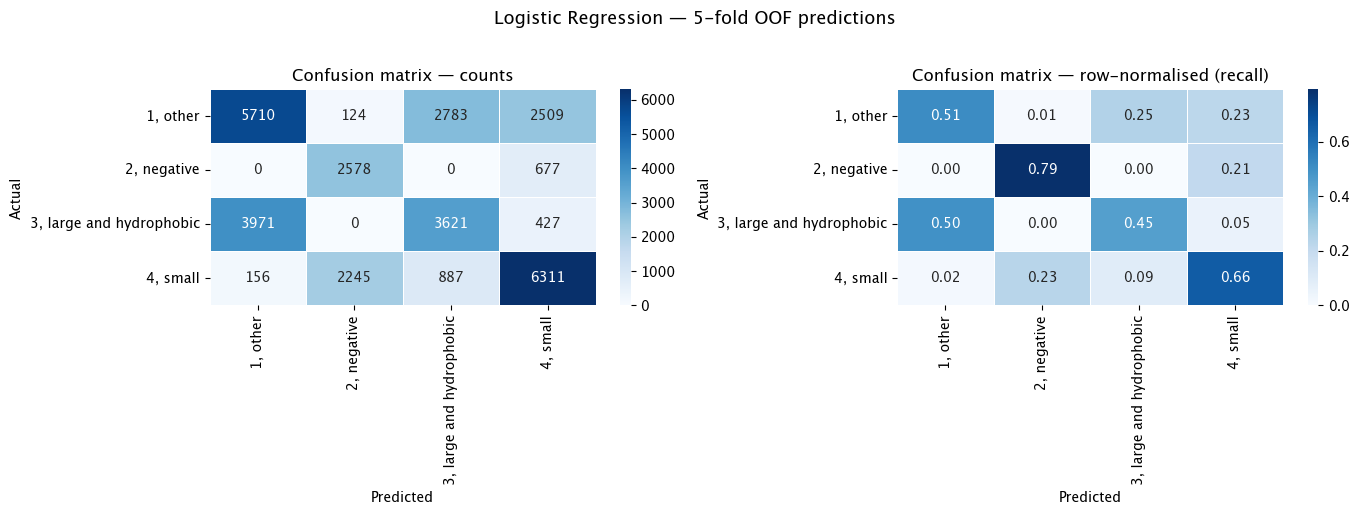

                          precision    recall  f1-score   support

                1, other       0.58      0.51      0.54     11126
             2, negative       0.52      0.79      0.63      3255
3, large and hydrophobic       0.50      0.45      0.47      8019
                4, small       0.64      0.66      0.65      9599

                accuracy                           0.57     31999
               macro avg       0.56      0.60      0.57     31999
            weighted avg       0.57      0.57      0.57     31999



In [24]:
valid = features.dropna(subset=['pred_LogisticRegression'])
y_true = valid['cluster_class']
y_pred = valid['pred_LogisticRegression']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_4)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_4, yticklabels=ORDER_4,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Logistic Regression — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_4, target_names=ORDER_4))

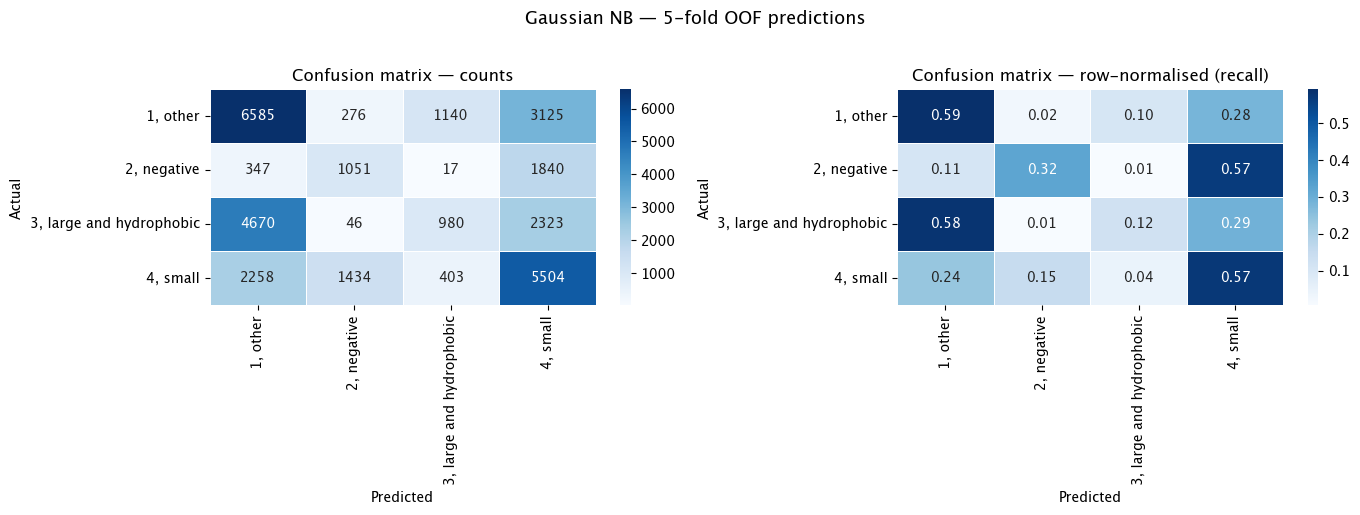

                          precision    recall  f1-score   support

                1, other       0.48      0.59      0.53     11126
             2, negative       0.37      0.32      0.35      3255
3, large and hydrophobic       0.39      0.12      0.19      8019
                4, small       0.43      0.57      0.49      9599

                accuracy                           0.44     31999
               macro avg       0.42      0.40      0.39     31999
            weighted avg       0.43      0.44      0.41     31999



In [26]:
valid = features.dropna(subset=['pred_GaussianNB'])
y_true = valid['cluster_class']
y_pred = valid['pred_GaussianNB']

cm_counts = confusion_matrix(y_true, y_pred, labels=ORDER_4)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Confusion matrix — counts', 'Confusion matrix — row-normalised (recall)'],
    ['d', '.2f']
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER_4, yticklabels=ORDER_4,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Gaussian NB — 5-fold OOF predictions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, labels=ORDER_4, target_names=ORDER_4))